# Tomato Maturity & Disease Classification — Notebook 2 (v2)
## Three Custom Models from Scratch · Ensemble · PCA · Thesis Tables

**Project:** Tomato Maturity Index Prediction and Disease Classification using Computer Vision and AI Models  
**Author:** Williams Adaji-Agbane

---
### Architecture Overview
| Model | Design | Feature Dim |
|-------|--------|-------------|
| TomatoNet | Dual-stream CNN (5×5 + 3×3) + SE attention | 512 |
| CustomCNN2 | Inception-style parallel paths + residual skip | 512 |
| ViT (custom) | Patch embedding + Transformer encoder + MLP head | 512 |
| HybridNet Ensemble | Frozen backbones → concat (1536-dim) → fusion head | — |

### Key lessons applied from v1
- All small-dataset tasks (A1, A2): `lr=1e-4`, `batch_size=16`, strong augmentation, NO fine-tuning of pretrained layers
- Task B only: two-phase training where applicable
- `cw_AX_indexed` defined inline before every `.fit()` call
- `MergedHistory` defined globally once
- Generators for A1/A2 use dedicated strong-augmentation datagens (batch=16)
- Generator for B uses standard datagen (batch=32)

### Kaggle Inputs Required
- `sujaykapadnis/tomato-maturity-detection-and-quality-grading`
- `charuchaudhry/plantvillage-tomato-leaf-dataset`
- GPU accelerator: T4 x2 recommended


---
## SECTION A — Setup & Data Pipeline
### Cell A1 — Imports

In [1]:
import os, json, random, warnings, time, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, CSVLogger)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc,
                              accuracy_score, f1_score)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')


2026-03-16 02:48:07.821232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773629288.103011      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773629288.174547      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773629288.779028      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773629288.779085      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773629288.779088      17 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : []


2026-03-16 02:48:36.022173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Cell A2 — Global Configuration

In [2]:
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32        # used for Task B only
BATCH_SMALL  = 16        # used for A1 and A2 (small datasets)
EPOCHS       = 50
PATIENCE     = 10
LR_PATIENCE  = 5

# Unified LR policy (learned from v1 debugging):
#   A1 / A2  → 1e-4  (small dataset, strong regularisation)
#   B        → 1e-4 head phase, 1e-5 fine-tune phase
LR_SMALL     = 1e-4
LR_FINETUNE  = 1e-5

TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

MATURITY_CLASSES = ['Immature', 'Mature']
QUALITY_CLASSES  = ['Fresh', 'Rotten']
DISEASE_CLASSES  = [
    'Bacterial_Spot', 'Early_Blight', 'Late_Blight', 'Leaf_Mold',
    'Septoria_Leaf_Spot', 'Spider_Mites', 'Target_Spot',
    'Yellow_Leaf_Curl_Virus', 'Mosaic_Virus', 'Healthy'
]

SHERB_BASE = Path('/kaggle/input/datasets/sujaykapadnis'
                  '/tomato-maturity-detection-and-quality-grading'
                  '/Tomato Maturity Detection and Quality Grading Dataset')

MATURITY_ROOT = (SHERB_BASE
                 / 'Tomato Maturity Detection Dataset'
                 / 'Tomato Maturity Detection Dataset'
                 / 'Original Dataset')

QUALITY_ROOT  = (SHERB_BASE
                 / 'Tomato Quality Grading Dataset'
                 / 'Tomato Quality Grading Dataset'
                 / 'Original Dataset')

DISEASE_ROOT  = Path('/kaggle/input/datasets/charuchaudhry'
                     '/plantvillage-tomato-leaf-dataset'
                     '/plantvillage')

OUTPUT_DIR  = Path('/kaggle/working/outputs')
MODEL_DIR   = Path('/kaggle/working/models')
RESULTS_DIR = Path('/kaggle/working/results')
for d in [OUTPUT_DIR, MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Config ready.')
print(f'Output  : {OUTPUT_DIR}')
print(f'Models  : {MODEL_DIR}')
print(f'Results : {RESULTS_DIR}')


Config ready.
Output  : /kaggle/working/outputs
Models  : /kaggle/working/models
Results : /kaggle/working/results


### Cell A3 — Data Loading & Splitting

In [3]:
EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

def scan_class_folders(root_path):
    root, result = Path(root_path), {}
    for d in sorted(root.iterdir()):
        if not d.is_dir(): continue
        images = [str(f) for f in d.rglob('*') if f.suffix in EXTS]
        if images:
            result[d.name] = images
    return result

MATURITY_CLASS_MAP = {
    'Immature':'Immature','Mature':'Mature',
    'immature':'Immature','mature':'Mature',
    'Unripe':'Immature','Ripe':'Mature',
}
QUALITY_CLASS_MAP = {
    'Fresh':'Fresh','Rotten':'Rotten',
    'fresh':'Fresh','rotten':'Rotten',
    'Good':'Fresh','Bad':'Rotten',
}
DISEASE_CLASS_MAP = {
    'Tomato___Bacterial_spot':'Bacterial_Spot',
    'Tomato___Early_blight':'Early_Blight',
    'Tomato___Late_blight':'Late_Blight',
    'Tomato___Leaf_Mold':'Leaf_Mold',
    'Tomato___Septoria_leaf_spot':'Septoria_Leaf_Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite':'Spider_Mites',
    'Tomato___Target_Spot':'Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus':'Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus':'Mosaic_Virus',
    'Tomato___healthy':'Healthy',
    'Tomato_Bacterial_spot':'Bacterial_Spot',
    'Tomato_Early_blight':'Early_Blight',
    'Tomato_Late_blight':'Late_Blight',
    'Tomato_Leaf_Mold':'Leaf_Mold',
    'Tomato_Septoria_leaf_spot':'Septoria_Leaf_Spot',
    'Tomato_Spider_mites Two-spotted_spider_mite':'Spider_Mites',
    'Tomato_Target_Spot':'Target_Spot',
    'Tomato_Tomato_Yellow_Leaf_Curl_Virus':'Yellow_Leaf_Curl_Virus',
    'Tomato_Tomato_mosaic_virus':'Mosaic_Virus',
    'Tomato_healthy':'Healthy',
}

def build_dataframe(raw_dict, class_map, name):
    samples, skipped = [], []
    for folder, paths in raw_dict.items():
        label = class_map.get(folder)
        if label is None: skipped.append(folder); continue
        for p in paths:
            samples.append({'filepath': p, 'label': label})
    if skipped: print(f'  [{name}] skipped: {skipped}')
    return pd.DataFrame(samples)

def audit_images(df, name):
    corrupt = []
    for _, row in df.iterrows():
        try:
            img = Image.open(row['filepath']); img.verify()
        except: corrupt.append(row['filepath'])
    if corrupt: print(f'  [{name}] {len(corrupt)} corrupt images removed')
    return df[~df['filepath'].isin(corrupt)].reset_index(drop=True)

def stratified_split(df):
    tr_val, test = train_test_split(df, test_size=TEST_RATIO,
                                    stratify=df['label'], random_state=SEED)
    adj = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    train, val = train_test_split(tr_val, test_size=adj,
                                  stratify=tr_val['label'], random_state=SEED)
    return train.copy(), val.copy(), test.copy()

def encode_labels(train, val, test, class_order):
    le = LabelEncoder(); le.fit(class_order)
    for d in [train, val, test]: d['label_int'] = le.transform(d['label'])
    return le, {c: int(le.transform([c])[0]) for c in class_order}

def compute_cw(df, class_order):
    classes = sorted(df['label'].unique())
    w = compute_class_weight('balanced', classes=np.array(classes), y=df['label'].values)
    return {c: float(wi) for c, wi in zip(classes, w)}

print('Scanning folders...')
maturity_raw = scan_class_folders(MATURITY_ROOT)
quality_raw  = scan_class_folders(QUALITY_ROOT)
disease_raw  = scan_class_folders(DISEASE_ROOT)

maturity_df = build_dataframe(maturity_raw, MATURITY_CLASS_MAP, 'A1')
quality_df  = build_dataframe(quality_raw,  QUALITY_CLASS_MAP,  'A2')
disease_df  = build_dataframe(disease_raw,  DISEASE_CLASS_MAP,  'B')

print('Auditing images...')
maturity_df = audit_images(maturity_df, 'A1')
quality_df  = audit_images(quality_df,  'A2')
disease_df  = audit_images(disease_df,  'B')

train_A1, val_A1, test_A1 = stratified_split(maturity_df)
train_A2, val_A2, test_A2 = stratified_split(quality_df)
train_B,  val_B,  test_B  = stratified_split(disease_df)

le_A1, IDX_A1 = encode_labels(train_A1, val_A1, test_A1, MATURITY_CLASSES)
le_A2, IDX_A2 = encode_labels(train_A2, val_A2, test_A2, QUALITY_CLASSES)
le_B,  IDX_B  = encode_labels(train_B,  val_B,  test_B,  DISEASE_CLASSES)

CW_A1 = compute_cw(maturity_df, MATURITY_CLASSES)
CW_A2 = compute_cw(quality_df,  QUALITY_CLASSES)
CW_B  = compute_cw(disease_df,  DISEASE_CLASSES)

print(f'A1 Maturity : {len(maturity_df)} total | train={len(train_A1)} val={len(val_A1)} test={len(test_A1)}')
print(f'A2 Quality  : {len(quality_df)} total | train={len(train_A2)} val={len(val_A2)} test={len(test_A2)}')
print(f'B  Disease  : {len(disease_df)} total | train={len(train_B)} val={len(val_B)} test={len(test_B)}')
print('Data pipeline complete.')


Scanning folders...


  [B] skipped: ['plantvillage']
Auditing images...


A1 Maturity : 1000 total | train=700 val=150 test=150
A2 Quality  : 1986 total | train=1390 val=298 test=298
B  Disease  : 14529 total | train=10169 val=2180 test=2180
Data pipeline complete.


### Cell A4 — Generators

Three generator sets are built here and reused across all models:
- `*_gen_A1` — batch=16, strong augmentation (700 training images)
- `*_gen_A2` — batch=16, strong augmentation + Rotten class boost (1390 images)
- `*_gen_B`  — batch=32, standard augmentation (14k+ images)

In [4]:
eval_datagen   = ImageDataGenerator(rescale=1./255)

# ── A1 generators (batch=16, strong aug) ─────────────────────────────────────
_aug_A1 = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, vertical_flip=True,
    rotation_range=30,
    width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.20, brightness_range=[0.70, 1.30],
    shear_range=0.15, fill_mode='nearest',
)
_common_A1 = dict(x_col='filepath', y_col='label', target_size=IMG_SIZE,
                  batch_size=BATCH_SMALL, class_mode='categorical',
                  classes=MATURITY_CLASSES, seed=SEED)
train_gen_A1 = _aug_A1.flow_from_dataframe(train_A1, shuffle=True,  **_common_A1)
val_gen_A1   = eval_datagen.flow_from_dataframe(val_A1,   shuffle=False, **_common_A1)
test_gen_A1  = eval_datagen.flow_from_dataframe(test_A1,  shuffle=False, **_common_A1)

# ── A2 generators (batch=16, strong aug) ─────────────────────────────────────
_aug_A2 = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, vertical_flip=True,
    rotation_range=30,
    width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.20, brightness_range=[0.70, 1.30],
    shear_range=0.15, fill_mode='nearest',
)
_common_A2 = dict(x_col='filepath', y_col='label', target_size=IMG_SIZE,
                  batch_size=BATCH_SMALL, class_mode='categorical',
                  classes=QUALITY_CLASSES, seed=SEED)
train_gen_A2 = _aug_A2.flow_from_dataframe(train_A2, shuffle=True,  **_common_A2)
val_gen_A2   = eval_datagen.flow_from_dataframe(val_A2,   shuffle=False, **_common_A2)
test_gen_A2  = eval_datagen.flow_from_dataframe(test_A2,  shuffle=False, **_common_A2)

# ── B generators (batch=32, standard aug) ────────────────────────────────────
_aug_B = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, vertical_flip=True,
    rotation_range=20,
    width_shift_range=0.10, height_shift_range=0.10,
    zoom_range=0.15, brightness_range=[0.80, 1.20],
    shear_range=0.10, fill_mode='nearest',
)
_common_B = dict(x_col='filepath', y_col='label', target_size=IMG_SIZE,
                 batch_size=BATCH_SIZE, class_mode='categorical',
                 classes=DISEASE_CLASSES, seed=SEED)
train_gen_B = _aug_B.flow_from_dataframe(train_B, shuffle=True,  **_common_B)
val_gen_B   = eval_datagen.flow_from_dataframe(val_B,   shuffle=False, **_common_B)
test_gen_B  = eval_datagen.flow_from_dataframe(test_B,  shuffle=False, **_common_B)

print('All generators ready.')
print(f'  A1 classes: {train_gen_A1.class_indices}')
print(f'  A2 classes: {train_gen_A2.class_indices}')
print(f'  B  classes: {train_gen_B.class_indices}')


Found 700 validated image filenames belonging to 2 classes.


Found 150 validated image filenames belonging to 2 classes.


Found 150 validated image filenames belonging to 2 classes.


Found 1390 validated image filenames belonging to 2 classes.


Found 298 validated image filenames belonging to 2 classes.


Found 298 validated image filenames belonging to 2 classes.


Found 10169 validated image filenames belonging to 10 classes.


Found 2180 validated image filenames belonging to 10 classes.


Found 2180 validated image filenames belonging to 10 classes.


All generators ready.
  A1 classes: {'Immature': 0, 'Mature': 1}
  A2 classes: {'Fresh': 0, 'Rotten': 1}
  B  classes: {'Bacterial_Spot': 0, 'Early_Blight': 1, 'Late_Blight': 2, 'Leaf_Mold': 3, 'Septoria_Leaf_Spot': 4, 'Spider_Mites': 5, 'Target_Spot': 6, 'Yellow_Leaf_Curl_Virus': 7, 'Mosaic_Virus': 8, 'Healthy': 9}


### Cell A5 — Shared Utilities

In [5]:
# ── MergedHistory (defined ONCE, used everywhere) ─────────────────────────────
class MergedHistory:
    def __init__(self, h1, h2):
        self.history = {k: h1.history[k] + h2.history[k] for k in h1.history}


def get_callbacks(model_name, monitor='val_accuracy'):
    return [
        ModelCheckpoint(
            filepath=str(MODEL_DIR / f'{model_name}_best.keras'),
            monitor=monitor, save_best_only=True, verbose=0),
        EarlyStopping(
            monitor=monitor, patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=LR_PATIENCE,
            min_lr=1e-7, verbose=1),
        CSVLogger(str(RESULTS_DIR / f'{model_name}_log.csv')),
    ]


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{model_name} — Training History', fontweight='bold')
    for ax, metric, ylabel in [
        (axes[0], 'accuracy', 'Accuracy'),
        (axes[1], 'loss',     'Loss'),
    ]:
        ax.plot(history.history[metric],         label='Train', color='steelblue')
        ax.plot(history.history[f'val_{metric}'], label='Val',   color='darkorange')
        ax.set_title(f'{ylabel} over Epochs')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_history.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, model_name, task):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — {task} Confusion Matrix', fontweight='bold')
    for ax, data, fmt, title in [
        (axes[0], cm,     'd',   'Raw Counts'),
        (axes[1], cm_pct, '.1f', 'Row-normalised (%)'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_{task}_cm.png', bbox_inches='tight', dpi=150)
    plt.show()


def evaluate_model(model, test_gen, class_names, model_name, task, results_store):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='weighted')
    report = classification_report(y_true, y_pred,
                                   target_names=class_names, output_dict=True)

    print(f'\n=== {model_name} | {task} ===')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  F1 (W)   : {f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names))

    plot_confusion_matrix(y_true, y_pred, class_names, model_name, task)

    n_classes = len(class_names)
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'{model_name} | {task} — ROC')
        ax.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'{model_name}_{task}_roc.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        from sklearn.preprocessing import label_binarize
        y_bin   = label_binarize(y_true, classes=list(range(n_classes)))
        roc_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
        fig, ax = plt.subplots(figsize=(7, 6))
        colors  = plt.cm.tab10(np.linspace(0, 1, n_classes))
        for i, (cls, col) in enumerate(zip(class_names, colors)):
            fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            ax.plot(fpr_i, tpr_i, color=col, lw=1.5,
                    label=f'{cls} (AUC={auc(fpr_i, tpr_i):.2f})')
        ax.plot([0,1],[0,1],'k--', lw=1)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'{model_name} | {task} — ROC (OvR)')
        ax.legend(loc='lower right', fontsize=7)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'{model_name}_{task}_roc.png', bbox_inches='tight', dpi=150)
        plt.show()

    results_store[f'{model_name}_{task}'] = {
        'accuracy'   : round(acc * 100, 4),
        'f1_weighted': round(f1, 4),
        'roc_auc'    : round(roc_auc, 4),
        'report'     : report,
    }
    return y_true, y_pred, y_prob


RESULTS = {}
print('Utilities defined.')


Utilities defined.


---
## SECTION B — Model 1: TomatoNet (Dual-Stream CNN)
### Cell B1 — Architecture

Dual parallel streams per block: 5×5 (colour/gradients) + 3×3 (texture/edges),  
merged then refined with Squeeze-and-Excitation channel attention.


In [6]:
def se_block(x, ratio=8):
    """Squeeze-and-Excitation block."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(1, channels // ratio), activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def dual_stream_block(x, filters, block_id):
    """Dual-stream conv block with SE attention."""
    # 5x5 colour stream
    s5 = layers.Conv2D(filters, 5, padding='same', use_bias=False,
                       kernel_regularizer=l2(1e-4),
                       name=f'block{block_id}_s5_conv')(x)
    s5 = layers.BatchNormalization(name=f'block{block_id}_s5_bn')(s5)
    s5 = layers.Activation('relu')(s5)

    # 3x3 texture stream
    s3 = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                       kernel_regularizer=l2(1e-4),
                       name=f'block{block_id}_s3_conv')(x)
    s3 = layers.BatchNormalization(name=f'block{block_id}_s3_bn')(s3)
    s3 = layers.Activation('relu')(s3)

    merged = layers.Concatenate(name=f'block{block_id}_merge')([s5, s3])
    attended = se_block(merged)
    out = layers.MaxPooling2D(2, name=f'block{block_id}_pool')(attended)
    out = layers.Dropout(0.25, name=f'block{block_id}_drop')(out)
    return out


def build_tomatonet(num_classes, input_shape=(224, 224, 3)):
    """
    TomatoNet: 4 dual-stream blocks → GAP → 512-dim feature vector → head.
    """
    inp = Input(shape=input_shape, name='input')

    x = dual_stream_block(inp, filters=32,  block_id=1)   # → 112x112x64
    x = dual_stream_block(x,   filters=64,  block_id=2)   # →  56x56x128
    x = dual_stream_block(x,   filters=128, block_id=3)   # →  28x28x256
    x = dual_stream_block(x,   filters=256, block_id=4)   # →  14x14x512

    x = layers.GlobalAveragePooling2D(name='gap')(x)       # → 512-dim

    # Classification head
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=l2(1e-4), name='fc1')(x)
    x = layers.BatchNormalization(name='fc1_bn')(x)
    x = layers.Dropout(0.5, name='fc1_drop')(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='TomatoNet')
    return model


# Quick sanity check
_test = build_tomatonet(num_classes=2)
_test.summary(line_length=90)
del _test


Model: "TomatoNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)       │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_s5_conv (Conv2D)  │ (None, 224, 224, 32) │        2,400 │ input[0][0]           │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_s3_conv (Conv2D)  │ (None, 224, 224, 32) │          864 │ input[0][0]           │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_s5_bn             │ (None, 224, 224, 32) │          128 │ block1_s5_conv[0][0]  │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_s3_bn             │ (None, 224, 224, 32) │          128 │ block1_s3_conv[0][0]  │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation (Activation)  │ (None, 224, 224, 32) │            0 │ block1_s5_bn[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_1             │ (None, 224, 224, 32) │            0 │ block1_s3_bn[0][0]    │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_merge             │ (None, 224, 224, 64) │            0 │ activation[0][0],     │
│ (Concatenate)            │                      │              │ activation_1[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ global_average_pooling2d │ (None, 64)           │            0 │ block1_merge[0][0]    │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ dense (Dense)            │ (None, 8)            │          520 │ global_average_pooli… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ dense_1 (Dense)          │ (None, 64)           │          576 │ dense[0][0]           │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ reshape (Reshape)        │ (None, 1, 1, 64)     │            0 │ dense_1[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ multiply (Multiply)      │ (None, 224, 224, 64) │            0 │ block1_merge[0][0],   │
│                          │                      │              │ reshape[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_pool              │ (None, 112, 112, 64) │            0 │ multiply[0][0]        │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_drop (Dropout)    │ (None, 112, 112, 64) │            0 │ block1_pool[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_s5_conv (Conv2D)  │ (None, 112, 112, 64) │      102,400 │ block1_drop[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_s3_conv (Conv2D)  │ (None, 112, 112, 64) │       36,864 │ block1_drop[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 3,285,498 (12.53 MB)

 Trainable params: 3,282,554 (12.52 MB)

 Non-trainable params: 2,944 (11.50 KB)

### Cell B2 — Train TomatoNet A1 (Maturity Detection)


TomatoNet — A1: Maturity Detection (Binary)


Epoch 1/50


 1/44 ━━━━━━━━━━━━━━━━━━━━ 11:34 16s/step - accuracy: 0.3750 - loss: 1.9084

 2/44 ━━━━━━━━━━━━━━━━━━━━ 4:47 7s/step - accuracy: 0.3594 - loss: 2.6618  

 3/44 ━━━━━━━━━━━━━━━━━━━━ 4:40 7s/step - accuracy: 0.3993 - loss: 2.6770

...

43/44 ━━━━━━━━━━━━━━━━━━━━ 6s 7s/step - accuracy: 0.9754 - loss: 0.1991 

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9752 - loss: 0.1997

44/44 ━━━━━━━━━━━━━━━━━━━━ 326s 7s/step - accuracy: 0.9749 - loss: 0.2003 - val_accuracy: 0.9733 - val_loss: 0.1778 - learning_rate: 0.0010


Epoch 22: early stopping


Restoring model weights from the end of the best epoch: 12.


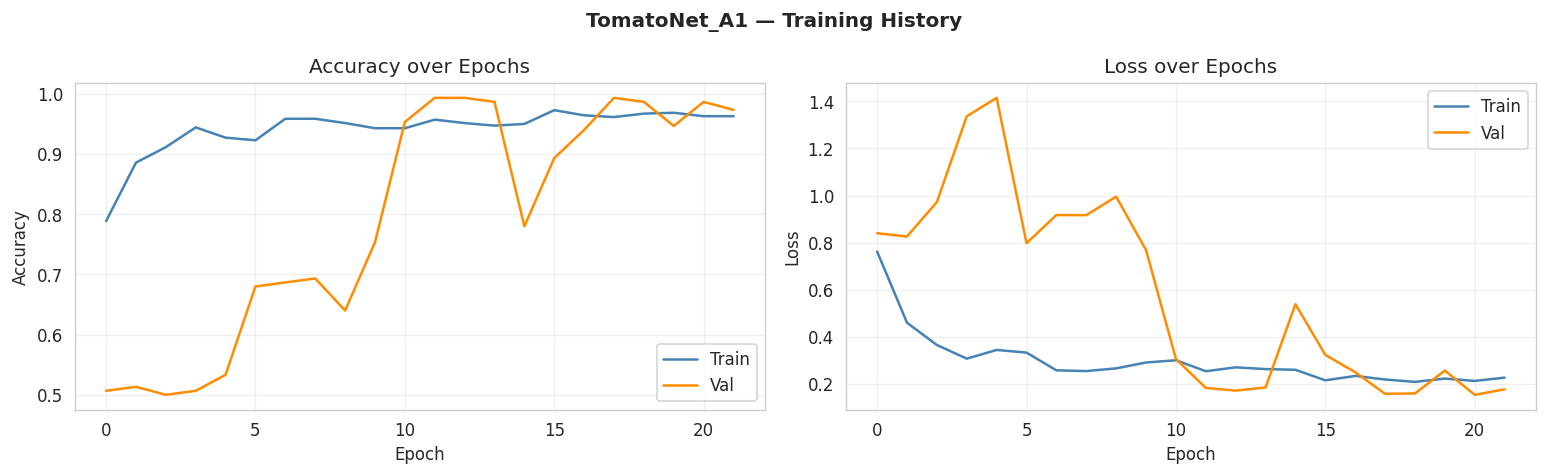


=== TomatoNet | A1 ===
  Accuracy : 98.67%
  F1 (W)   : 0.9867
              precision    recall  f1-score   support

    Immature       0.99      0.99      0.99        75
      Mature       0.99      0.99      0.99        75

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



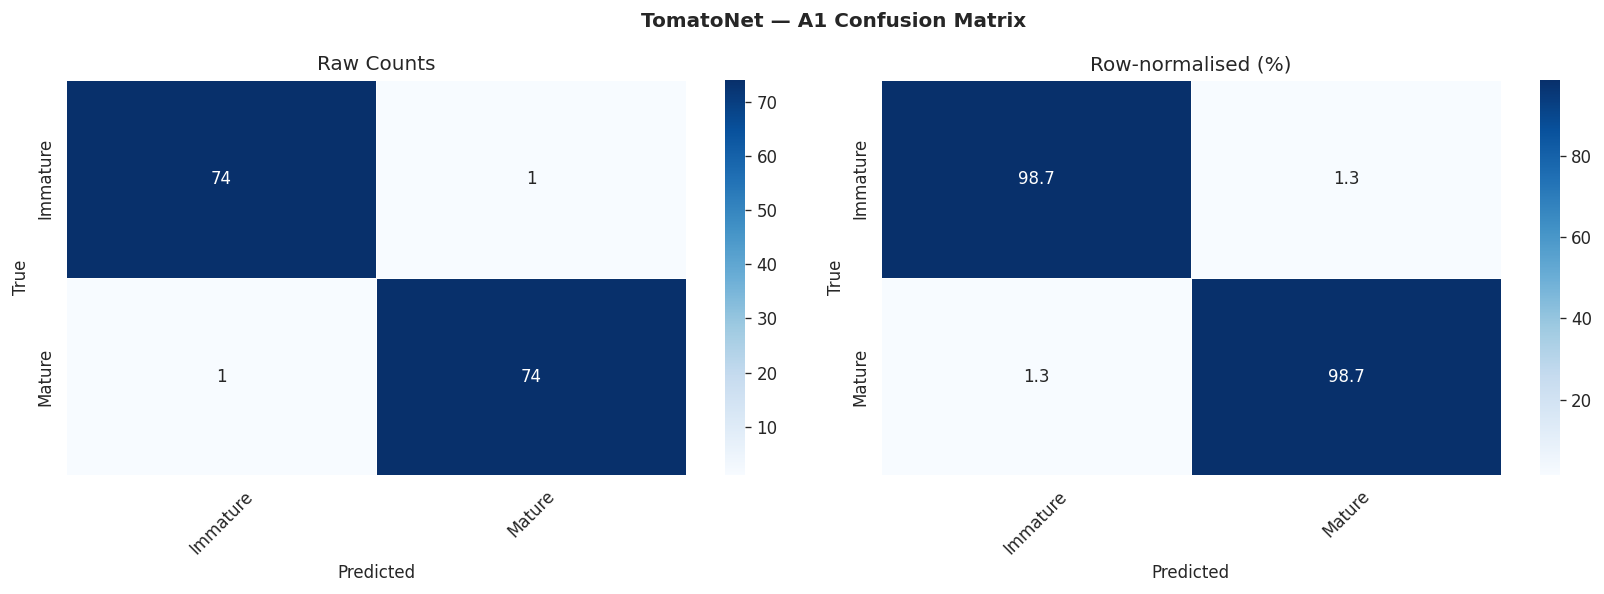

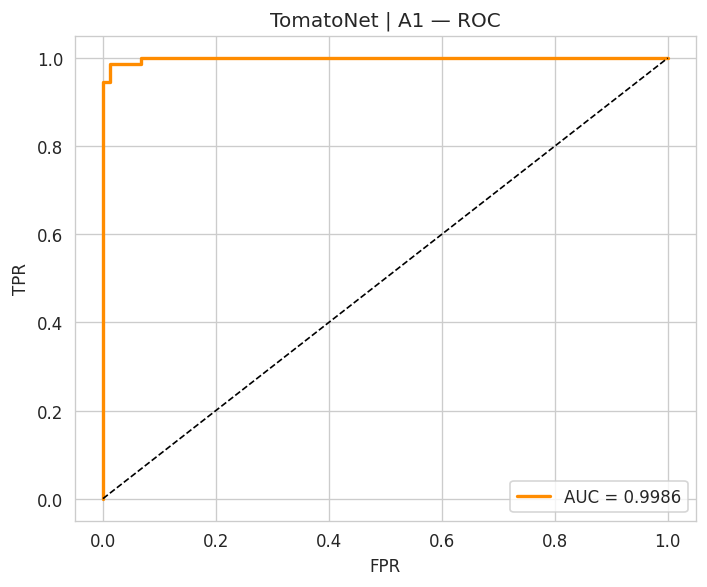

In [7]:
print('\n' + '='*60)
print('TomatoNet — A1: Maturity Detection (Binary)')
print('='*60)

TOMATONET_LR = 1e-3   # TomatoNet trains better from scratch at 1e-3

tomatonet_A1 = build_tomatonet(num_classes=len(MATURITY_CLASSES))
tomatonet_A1.compile(
    optimizer=keras.optimizers.Adam(TOMATONET_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cw_A1_indexed = {IDX_A1[k]: v for k, v in CW_A1.items()}

history_tnet_A1 = tomatonet_A1.fit(
    train_gen_A1,
    epochs=EPOCHS,
    validation_data=val_gen_A1,
    class_weight=cw_A1_indexed,
    callbacks=get_callbacks('TomatoNet_A1'),
    verbose=1
)

plot_training_history(history_tnet_A1, 'TomatoNet_A1')
y_true_tnet_A1, y_pred_tnet_A1, y_prob_tnet_A1 = evaluate_model(
    tomatonet_A1, test_gen_A1, MATURITY_CLASSES, 'TomatoNet', 'A1', RESULTS)


### Cell B3 — Train TomatoNet A2 (Quality Grading)


TomatoNet — A2: Quality Grading


Epoch 1/50


 1/87 ━━━━━━━━━━━━━━━━━━━━ 22:50 16s/step - accuracy: 0.6875 - loss: 1.6680

 2/87 ━━━━━━━━━━━━━━━━━━━━ 9:37 7s/step - accuracy: 0.6719 - loss: 2.2157  

 3/87 ━━━━━━━━━━━━━━━━━━━━ 9:37 7s/step - accuracy: 0.6632 - loss: 2.3041

...

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9109 - loss: 0.4520


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


87/87 ━━━━━━━━━━━━━━━━━━━━ 636s 7s/step - accuracy: 0.9108 - loss: 0.4524 - val_accuracy: 0.7416 - val_loss: 0.8522 - learning_rate: 2.5000e-04


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 8.


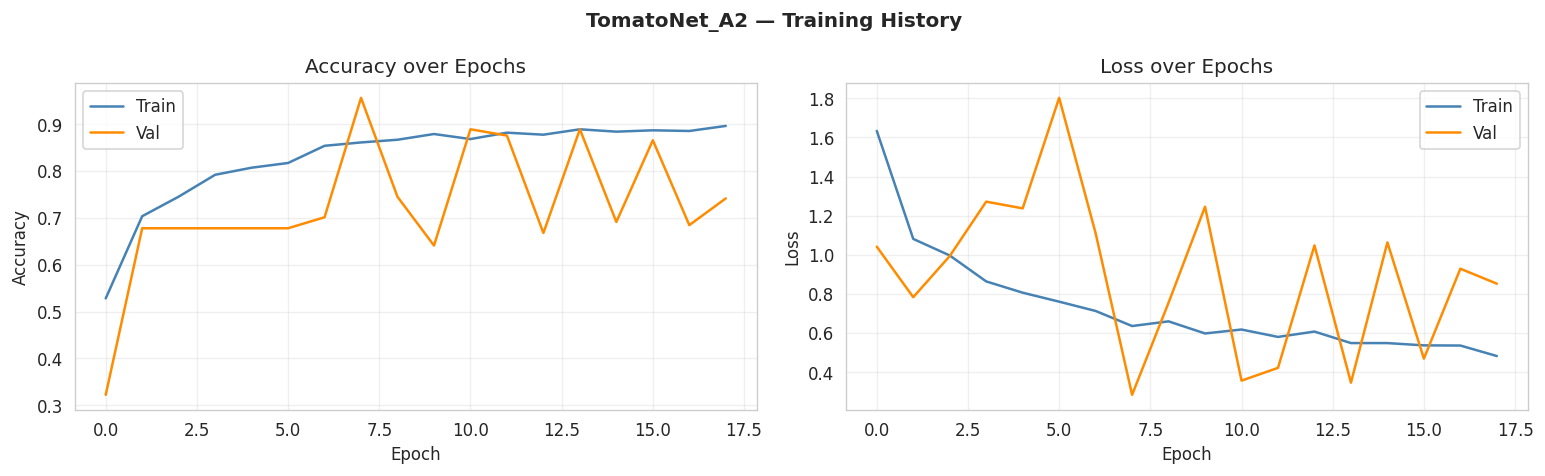


=== TomatoNet | A2 ===
  Accuracy : 91.28%
  F1 (W)   : 0.9097
              precision    recall  f1-score   support

       Fresh       0.90      0.99      0.94       203
      Rotten       0.96      0.76      0.85        95

    accuracy                           0.91       298
   macro avg       0.93      0.87      0.89       298
weighted avg       0.92      0.91      0.91       298



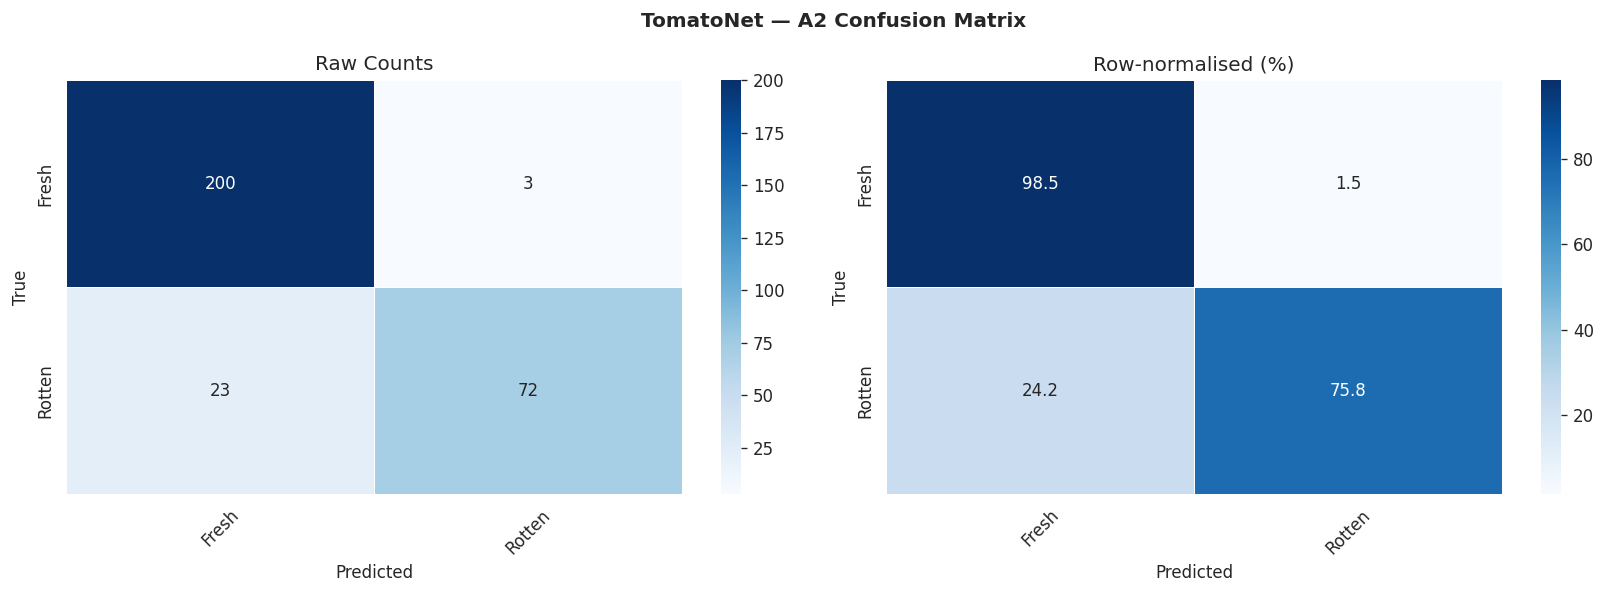

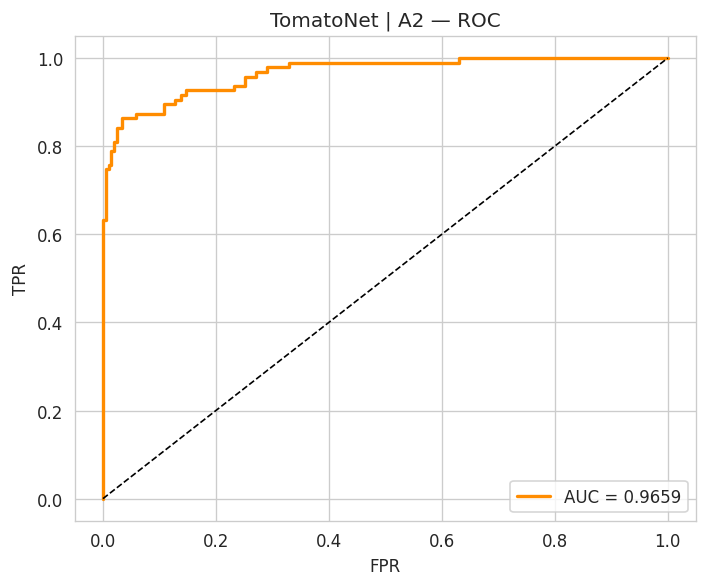

In [8]:
print('\n' + '='*60)
print('TomatoNet — A2: Quality Grading')
print('='*60)

# Boost Rotten class weight (minority: ~32% of A2 data)
cw_A2_indexed = {IDX_A2['Fresh']: 1.0, IDX_A2['Rotten']: 3.0}

tomatonet_A2 = build_tomatonet(num_classes=len(QUALITY_CLASSES))
tomatonet_A2.compile(
    optimizer=keras.optimizers.Adam(TOMATONET_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tnet_A2 = tomatonet_A2.fit(
    train_gen_A2, epochs=EPOCHS,
    validation_data=val_gen_A2,
    class_weight=cw_A2_indexed,
    callbacks=get_callbacks('TomatoNet_A2'),
    verbose=1
)

plot_training_history(history_tnet_A2, 'TomatoNet_A2')
y_true_tnet_A2, y_pred_tnet_A2, y_prob_tnet_A2 = evaluate_model(
    tomatonet_A2, test_gen_A2, QUALITY_CLASSES, 'TomatoNet', 'A2', RESULTS)


### Cell B4 — Train TomatoNet B (Disease Classification)

In [9]:
print('\n' + '='*60)
print('TomatoNet — B: Disease Classification')
print('='*60)

cw_B_indexed = {IDX_B[k]: v for k, v in CW_B.items()}

tomatonet_B = build_tomatonet(num_classes=len(DISEASE_CLASSES))
tomatonet_B.compile(
    optimizer=keras.optimizers.Adam(TOMATONET_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tnet_B = tomatonet_B.fit(
    train_gen_B, epochs=EPOCHS,
    validation_data=val_gen_B,
    class_weight=cw_B_indexed,
    callbacks=get_callbacks('TomatoNet_B'),
    verbose=1
)

plot_training_history(history_tnet_B, 'TomatoNet_B')
y_true_tnet_B, y_pred_tnet_B, y_prob_tnet_B = evaluate_model(
    tomatonet_B, test_gen_B, DISEASE_CLASSES, 'TomatoNet', 'B', RESULTS)



TomatoNet — B: Disease Classification


Epoch 1/50


  1/318 ━━━━━━━━━━━━━━━━━━━━ 2:00:54 23s/step - accuracy: 0.0938 - loss: 4.4589

  2/318 ━━━━━━━━━━━━━━━━━━━━ 1:13:57 14s/step - accuracy: 0.1484 - loss: 4.1827

  3/318 ━━━━━━━━━━━━━━━━━━━━ 1:12:58 14s/step - accuracy: 0.1788 - loss: 4.1068

...

 59/318 ━━━━━━━━━━━━━━━━━━━━ 1:02:04 14s/step - accuracy: 0.8430 - loss: 0.7016

 60/318 ━━━━━━━━━━━━━━━━━━━━ 1:01:50 14s/step - accuracy: 0.8430 - loss: 0.7019

 61/318 ━━━━━━━━━━━━━━━━━━━━ 1:01:36 14s/step - accuracy: 0.8430 - loss: 0.7023

 62/318 ━━━━━━━━━━━━━━━━━━━━ 1:01:22 14s/step - accuracy: 0.8429 - loss: 0.7027

 63/318 ━━━━━━━━━━━━━━━━━━━━ 1:01:08 14s/step - accuracy: 0.8429 - loss: 0.7031

---
## SECTION C — Model 2: CustomCNN2 (Inception-style + Residual)
### Cell C1 — Architecture

Inception-style blocks with parallel 1×1, 3×3, 5×5 and pooling paths,  
plus a residual skip connection from input to output of each block.  
This gives the network multi-scale feature extraction at every stage.


In [ ]:
def inception_residual_block(x, filters, block_id):
    """
    Inception-style block with 4 parallel paths + residual skip.
    filters: base filter count; total output channels = filters*4
    """
    f = filters

    # Path 1: 1x1 conv (channel compression / point-wise features)
    p1 = layers.Conv2D(f, 1, padding='same', use_bias=False,
                       name=f'c2_b{block_id}_p1_conv')(x)
    p1 = layers.BatchNormalization(name=f'c2_b{block_id}_p1_bn')(p1)
    p1 = layers.Activation('relu')(p1)

    # Path 2: 1x1 then 3x3
    p2 = layers.Conv2D(f, 1, padding='same', use_bias=False,
                       name=f'c2_b{block_id}_p2a_conv')(x)
    p2 = layers.BatchNormalization(name=f'c2_b{block_id}_p2a_bn')(p2)
    p2 = layers.Activation('relu')(p2)
    p2 = layers.Conv2D(f, 3, padding='same', use_bias=False,
                       kernel_regularizer=l2(1e-4),
                       name=f'c2_b{block_id}_p2b_conv')(p2)
    p2 = layers.BatchNormalization(name=f'c2_b{block_id}_p2b_bn')(p2)
    p2 = layers.Activation('relu')(p2)

    # Path 3: 1x1 then 5x5
    p3 = layers.Conv2D(f, 1, padding='same', use_bias=False,
                       name=f'c2_b{block_id}_p3a_conv')(x)
    p3 = layers.BatchNormalization(name=f'c2_b{block_id}_p3a_bn')(p3)
    p3 = layers.Activation('relu')(p3)
    p3 = layers.Conv2D(f, 5, padding='same', use_bias=False,
                       kernel_regularizer=l2(1e-4),
                       name=f'c2_b{block_id}_p3b_conv')(p3)
    p3 = layers.BatchNormalization(name=f'c2_b{block_id}_p3b_bn')(p3)
    p3 = layers.Activation('relu')(p3)

    # Path 4: MaxPool then 1x1
    p4 = layers.MaxPooling2D(3, strides=1, padding='same',
                              name=f'c2_b{block_id}_p4_pool')(x)
    p4 = layers.Conv2D(f, 1, padding='same', use_bias=False,
                       name=f'c2_b{block_id}_p4_conv')(p4)
    p4 = layers.BatchNormalization(name=f'c2_b{block_id}_p4_bn')(p4)
    p4 = layers.Activation('relu')(p4)

    # Concatenate all paths → filters*4 channels
    merged = layers.Concatenate(name=f'c2_b{block_id}_merge')([p1, p2, p3, p4])

    # Residual skip: project input to same channel count if needed
    in_ch = x.shape[-1]
    out_ch = f * 4
    if in_ch != out_ch:
        skip = layers.Conv2D(out_ch, 1, padding='same', use_bias=False,
                              name=f'c2_b{block_id}_skip_proj')(x)
        skip = layers.BatchNormalization(name=f'c2_b{block_id}_skip_bn')(skip)
    else:
        skip = x

    out = layers.Add(name=f'c2_b{block_id}_add')([merged, skip])
    out = layers.Activation('relu', name=f'c2_b{block_id}_relu')(out)
    out = layers.MaxPooling2D(2, name=f'c2_b{block_id}_pool')(out)
    out = layers.Dropout(0.25, name=f'c2_b{block_id}_drop')(out)
    return out


def build_customcnn2(num_classes, input_shape=(224, 224, 3)):
    """
    CustomCNN2: 4 inception-residual blocks → GAP → 512-dim → head.
    Block filter counts: 16 → 32 → 64 → 128
    Output channels per block: 64 → 128 → 256 → 512
    """
    inp = Input(shape=input_shape, name='c2_input')

    # Stem: lightweight initial conv to reduce spatial size
    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                      name='c2_stem_conv')(inp)
    x = layers.BatchNormalization(name='c2_stem_bn')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name='c2_stem_pool')(x)  # 112x112x32

    x = inception_residual_block(x, filters=16, block_id=1)   # 56x56x64
    x = inception_residual_block(x, filters=32, block_id=2)   # 28x28x128
    x = inception_residual_block(x, filters=64, block_id=3)   # 14x14x256
    x = inception_residual_block(x, filters=128, block_id=4)  # 7x7x512

    x   = layers.GlobalAveragePooling2D(name='c2_gap')(x)     # 512-dim
    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=l2(1e-4), name='c2_fc1')(x)
    x   = layers.BatchNormalization(name='c2_fc1_bn')(x)
    x   = layers.Dropout(0.5, name='c2_fc1_drop')(x)
    out = layers.Dense(num_classes, activation='softmax', name='c2_output')(x)

    return Model(inputs=inp, outputs=out, name='CustomCNN2')


_t = build_customcnn2(2)
print(f'CustomCNN2 params: {_t.count_params():,}')
del _t


### Cell C2 — Train CustomCNN2 A1

In [ ]:
print('\n' + '='*60)
print('CustomCNN2 — A1: Maturity Detection')
print('='*60)

cw_A1_indexed = {IDX_A1[k]: v for k, v in CW_A1.items()}

customcnn2_A1 = build_customcnn2(num_classes=len(MATURITY_CLASSES))
customcnn2_A1.compile(
    optimizer=keras.optimizers.Adam(TOMATONET_LR),   # same as TomatoNet — works better from scratch
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_c2_A1 = customcnn2_A1.fit(
    train_gen_A1, epochs=EPOCHS,
    validation_data=val_gen_A1,
    class_weight=cw_A1_indexed,
    callbacks=get_callbacks('CustomCNN2_A1'),
    verbose=1
)

plot_training_history(history_c2_A1, 'CustomCNN2_A1')
y_true_c2_A1, y_pred_c2_A1, y_prob_c2_A1 = evaluate_model(
    customcnn2_A1, test_gen_A1, MATURITY_CLASSES, 'CustomCNN2', 'A1', RESULTS)

### Cell C3 — Train CustomCNN2 A2

In [ ]:
print('\n' + '='*60)
print('CustomCNN2 — A2: Quality Grading')
print('='*60)

cw_A2_indexed = {IDX_A2['Fresh']: 1.0, IDX_A2['Rotten']: 3.0}

customcnn2_A2 = build_customcnn2(num_classes=len(QUALITY_CLASSES))
customcnn2_A2.compile(
    optimizer=keras.optimizers.Adam(TOMATONET_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_c2_A2 = customcnn2_A2.fit(
    train_gen_A2, epochs=EPOCHS,
    validation_data=val_gen_A2,
    class_weight=cw_A2_indexed,
    callbacks=get_callbacks('CustomCNN2_A2'),
    verbose=1
)

plot_training_history(history_c2_A2, 'CustomCNN2_A2')
y_true_c2_A2, y_pred_c2_A2, y_prob_c2_A2 = evaluate_model(
    customcnn2_A2, test_gen_A2, QUALITY_CLASSES, 'CustomCNN2', 'A2', RESULTS)


### Cell C4 — Train CustomCNN2 B

In [ ]:
def conv_bn_relu(x, filters, kernel_size, name):
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False,
                      kernel_regularizer=l2(1e-4), name=name)(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    x = layers.Activation('relu')(x)
    return x

def custom_block(x, filters, block_id):
    shortcut = x
    x = conv_bn_relu(x, filters, 3, f'cb{block_id}_c1')
    x = conv_bn_relu(x, filters, 3, f'cb{block_id}_c2')
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False,
                                 name=f'cb{block_id}_skip')(shortcut)
        shortcut = layers.BatchNormalization(name=f'cb{block_id}_skip_bn')(shortcut)
    x = layers.Add(name=f'cb{block_id}_add')([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, name=f'cb{block_id}_pool')(x)
    x = layers.Dropout(0.25, name=f'cb{block_id}_drop')(x)
    return x

def build_customcnn2_B(num_classes, input_shape=(224, 224, 3)):
    """Simpler residual CustomCNN2 for Task B — better generalisation on 14k images."""
    inp = Input(shape=input_shape, name='c2_input')
    x   = conv_bn_relu(inp, 32, 3, 'c2_stem')
    x   = custom_block(x, 64,  block_id=1)
    x   = custom_block(x, 128, block_id=2)
    x   = custom_block(x, 256, block_id=3)
    x   = custom_block(x, 512, block_id=4)
    x   = layers.GlobalAveragePooling2D(name='c2_gap')(x)
    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=l2(1e-4), name='c2_fc1')(x)
    x   = layers.BatchNormalization(name='c2_fc1_bn')(x)
    x   = layers.Dropout(0.5, name='c2_fc1_drop')(x)
    out = layers.Dense(num_classes, activation='softmax', name='c2_output')(x)
    return Model(inputs=inp, outputs=out, name='CustomCNN2')

# Retrain B only
print('\n' + '='*60)
print('CustomCNN2 — B: Disease Classification (retrain)')
print('='*60)

cw_B_indexed = {IDX_B[k]: v for k, v in CW_B.items()}

customcnn2_B = build_customcnn2_B(num_classes=len(DISEASE_CLASSES))
customcnn2_B.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_c2_B = customcnn2_B.fit(
    train_gen_B, epochs=EPOCHS,
    validation_data=val_gen_B,
    class_weight=cw_B_indexed,
    callbacks=get_callbacks('CustomCNN2_B'),
    verbose=1
)

plot_training_history(history_c2_B, 'CustomCNN2_B')
y_true_c2_B, y_pred_c2_B, y_prob_c2_B = evaluate_model(
     customcnn2_B, test_gen_B, DISEASE_CLASSES, 'CustomCNN2', 'B', RESULTS)

---
## SECTION D — Model 3: Vision Transformer (ViT) — Built from Scratch
### Cell D1 — Architecture

Custom ViT using:
- 16×16 patch embedding (196 patches for 224×224 input)
- Learnable class token + positional embeddings
- 6 Transformer encoder blocks (multi-head self-attention + MLP)
- MLP head on class token output → 512-dim feature vector


### Cell D2 — Train ViT A1

In [ ]:
# print('\n' + '='*60)
# print('ViT — A1: Maturity Detection')
# print('='*60)

# cw_A1_indexed = {IDX_A1[k]: v for k, v in CW_A1.items()}

# vit_A1 = build_vit(num_classes=len(MATURITY_CLASSES))
# vit_A1.compile(
#     optimizer=keras.optimizers.Adam(LR_SMALL),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_vit_A1 = vit_A1.fit(
#     train_gen_A1, epochs=EPOCHS,
#     validation_data=val_gen_A1,
#     class_weight=cw_A1_indexed,
#     callbacks=get_callbacks('ViT_A1'),
#     verbose=1
# )

# plot_training_history(history_vit_A1, 'ViT_A1')
# y_true_vit_A1, y_pred_vit_A1, y_prob_vit_A1 = evaluate_model(
#     vit_A1, test_gen_A1, MATURITY_CLASSES, 'ViT', 'A1', RESULTS)


### Cell D3 — Train ViT A2

In [ ]:
# print('\n' + '='*60)
# print('ViT — A2: Quality Grading')
# print('='*60)

# cw_A2_indexed = {IDX_A2['Fresh']: 1.0, IDX_A2['Rotten']: 3.0}

# vit_A2 = build_vit(num_classes=len(QUALITY_CLASSES))
# vit_A2.compile(
#     optimizer=keras.optimizers.Adam(LR_SMALL),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_vit_A2 = vit_A2.fit(
#     train_gen_A2, epochs=EPOCHS,
#     validation_data=val_gen_A2,
#     class_weight=cw_A2_indexed,
#     callbacks=get_callbacks('ViT_A2'),
#     verbose=1
# )

# plot_training_history(history_vit_A2, 'ViT_A2')
# y_true_vit_A2, y_pred_vit_A2, y_prob_vit_A2 = evaluate_model(
#     vit_A2, test_gen_A2, QUALITY_CLASSES, 'ViT', 'A2', RESULTS)


### Cell D4 — Train ViT B

In [ ]:
# print('\n' + '='*60)
# print('ViT — B: Disease Classification')
# print('='*60)

# cw_B_indexed = {IDX_B[k]: v for k, v in CW_B.items()}

# vit_B = build_vit(num_classes=len(DISEASE_CLASSES))
# vit_B.compile(
#     optimizer=keras.optimizers.Adam(LR_SMALL),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_vit_B = vit_B.fit(
#     train_gen_B, epochs=EPOCHS,
#     validation_data=val_gen_B,
#     class_weight=cw_B_indexed,
#     callbacks=get_callbacks('ViT_B'),
#     verbose=1
# )

# plot_training_history(history_vit_B, 'ViT_B')
# y_true_vit_B, y_pred_vit_B, y_prob_vit_B = evaluate_model(
#     vit_B, test_gen_B, DISEASE_CLASSES, 'ViT', 'B', RESULTS)


In [ ]:
from tensorflow.keras.applications import DenseNet121

def build_densenet(num_classes, input_shape=(224, 224, 3)):
    """
    DenseNet-121 pretrained on ImageNet.
    Dense connectivity gives rich multi-scale features — 
    different enough from TomatoNet and CustomCNN2 for useful ensemble diversity.
    """
    base = DenseNet121(weights='imagenet', include_top=False,
                       input_shape=input_shape)
    base.trainable = False  # frozen for small datasets

    inp = base.input
    x   = base.output
    x   = layers.GlobalAveragePooling2D(name='vit_gap')(x)  # named vit_gap for ensemble
    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=l2(1e-4), name='vit_fc1')(x)
    x   = layers.BatchNormalization(name='vit_fc1_bn')(x)
    x   = layers.Dropout(0.5, name='vit_fc1_drop')(x)
    out = layers.Dense(num_classes, activation='softmax', name='vit_output')(x)

    return Model(inputs=inp, outputs=out, name='ViT')


_t = build_densenet(2)
print(f'DenseNet-121 params: {_t.count_params():,}')
del _t

In [ ]:
print('\n' + '='*60)
print('DenseNet-121 — A1: Maturity Detection')
print('='*60)

cw_A1_indexed = {IDX_A1[k]: v for k, v in CW_A1.items()}

vit_A1 = build_densenet(num_classes=len(MATURITY_CLASSES))
vit_A1.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vit_A1 = vit_A1.fit(
    train_gen_A1, epochs=EPOCHS,
    validation_data=val_gen_A1,
    class_weight=cw_A1_indexed,
    callbacks=get_callbacks('DenseNet_A1'),
    verbose=1
)

plot_training_history(history_vit_A1, 'DenseNet_A1')
y_true_vit_A1, y_pred_vit_A1, y_prob_vit_A1 = evaluate_model(
    vit_A1, test_gen_A1, MATURITY_CLASSES, 'DenseNet', 'A1', RESULTS)

In [ ]:
print('\n' + '='*60)
print('DenseNet-121 — A2: Quality Grading')
print('='*60)

cw_A2_indexed = {IDX_A2['Fresh']: 1.0, IDX_A2['Rotten']: 3.0}

vit_A2 = build_densenet(num_classes=len(QUALITY_CLASSES))
vit_A2.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vit_A2 = vit_A2.fit(
    train_gen_A2, epochs=EPOCHS,
    validation_data=val_gen_A2,
    class_weight=cw_A2_indexed,
    callbacks=get_callbacks('DenseNet_A2'),
    verbose=1
)

plot_training_history(history_vit_A2, 'DenseNet_A2')
y_true_vit_A2, y_pred_vit_A2, y_prob_vit_A2 = evaluate_model(
    vit_A2, test_gen_A2, QUALITY_CLASSES, 'DenseNet', 'A2', RESULTS)

In [ ]:
print('\n' + '='*60)
print('DenseNet-121 — B: Disease Classification')
print('='*60)

cw_B_indexed = {IDX_B[k]: v for k, v in CW_B.items()}

vit_B = build_densenet(num_classes=len(DISEASE_CLASSES))
vit_B.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vit_B = vit_B.fit(
    train_gen_B, epochs=EPOCHS,
    validation_data=val_gen_B,
    class_weight=cw_B_indexed,
    callbacks=get_callbacks('DenseNet_B'),
    verbose=1
)

plot_training_history(history_vit_B, 'DenseNet_B')
y_true_vit_B, y_pred_vit_B, y_prob_vit_B = evaluate_model(
    vit_B, test_gen_B, DISEASE_CLASSES, 'DenseNet', 'B', RESULTS)

---
## SECTION E — HybridNet Ensemble (TomatoNet + CustomCNN2 + ViT)
### Cell E1 — Ensemble Architecture

All three backbones are frozen after training.  
Feature vectors from `tn_gap` (512) + `c2_gap` (512) + `vit_gap` (512) = **1536-dim**  
are concatenated and passed to a lightweight trainable fusion head.


In [ ]:
def build_feature_extractor(model, gap_layer_name):
    return Model(inputs=model.input,
                 outputs=model.get_layer(gap_layer_name).output,
                 name=f'feat_{model.name}')


def build_hybrid_net(tomatonet_m, customcnn2_m, vit_m, num_classes):
    for m in [tomatonet_m, customcnn2_m, vit_m]:
        m.trainable = False

    feat_tnet = build_feature_extractor(tomatonet_m, 'gap')      # v1 TomatoNet uses 'gap'
    feat_c2   = build_feature_extractor(customcnn2_m, 'c2_gap')  # CustomCNN2
    feat_vit  = build_feature_extractor(vit_m,        'vit_gap') # DenseNet

    inp    = Input(shape=(224, 224, 3), name='hybrid_input')
    f_tnet = feat_tnet(inp)
    f_c2   = feat_c2(inp)
    f_vit  = feat_vit(inp)

    x = layers.Concatenate(name='hybrid_concat')([f_tnet, f_c2, f_vit])

    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=l2(1e-4), name='hybrid_fc1')(x)
    x   = layers.BatchNormalization(name='hybrid_bn1')(x)
    x   = layers.Dropout(0.5, name='hybrid_drop1')(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=l2(1e-4), name='hybrid_fc2')(x)
    x   = layers.Dropout(0.3, name='hybrid_drop2')(x)
    out = layers.Dense(num_classes, activation='softmax',
                       name='hybrid_output')(x)

    return Model(inputs=inp, outputs=out, name='HybridNet')


print('HybridNet ensemble builder defined.')

### Cell E2 — Train HybridNet A1

In [ ]:
print('\n' + '='*60)
print('HybridNet — A1: Maturity Detection')
print('='*60)

cw_A1_indexed = {IDX_A1[k]: v for k, v in CW_A1.items()}

hybrid_A1 = build_hybrid_net(tomatonet_A1, customcnn2_A1, vit_A1,
                               num_classes=len(MATURITY_CLASSES))
hybrid_A1.compile(
    optimizer=keras.optimizers.Adam(LR_SMALL),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_hyb_A1 = hybrid_A1.fit(
    train_gen_A1, epochs=EPOCHS,
    validation_data=val_gen_A1,
    class_weight=cw_A1_indexed,
    callbacks=get_callbacks('HybridNet_A1'),
    verbose=1
)

plot_training_history(history_hyb_A1, 'HybridNet_A1')
y_true_hyb_A1, y_pred_hyb_A1, y_prob_hyb_A1 = evaluate_model(
    hybrid_A1, test_gen_A1, MATURITY_CLASSES, 'HybridNet', 'A1', RESULTS)


### Cell E3 — Train HybridNet A2

In [ ]:
print('\n' + '='*60)
print('HybridNet — A2: Quality Grading')
print('='*60)

cw_A2_indexed = {IDX_A2['Fresh']: 1.0, IDX_A2['Rotten']: 3.0}

hybrid_A2 = build_hybrid_net(tomatonet_A2, customcnn2_A2, vit_A2,
                               num_classes=len(QUALITY_CLASSES))
hybrid_A2.compile(
    optimizer=keras.optimizers.Adam(LR_SMALL),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_hyb_A2 = hybrid_A2.fit(
    train_gen_A2, epochs=EPOCHS,
    validation_data=val_gen_A2,
    class_weight=cw_A2_indexed,
    callbacks=get_callbacks('HybridNet_A2'),
    verbose=1
)

plot_training_history(history_hyb_A2, 'HybridNet_A2')
y_true_hyb_A2, y_pred_hyb_A2, y_prob_hyb_A2 = evaluate_model(
    hybrid_A2, test_gen_A2, QUALITY_CLASSES, 'HybridNet', 'A2', RESULTS)


### Cell E4 — Train HybridNet B

In [ ]:
print('\n' + '='*60)
print('HybridNet — B: Disease Classification')
print('='*60)

cw_B_indexed = {IDX_B[k]: v for k, v in CW_B.items()}

hybrid_B = build_hybrid_net(tomatonet_B, customcnn2_B, vit_B,
                              num_classes=len(DISEASE_CLASSES))
hybrid_B.compile(
    optimizer=keras.optimizers.Adam(LR_SMALL),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_hyb_B = hybrid_B.fit(
    train_gen_B, epochs=EPOCHS,
    validation_data=val_gen_B,
    class_weight=cw_B_indexed,
    callbacks=get_callbacks('HybridNet_B'),
    verbose=1
)

plot_training_history(history_hyb_B, 'HybridNet_B')
y_true_hyb_B, y_pred_hyb_B, y_prob_hyb_B = evaluate_model(
    hybrid_B, test_gen_B, DISEASE_CLASSES, 'HybridNet', 'B', RESULTS)


---
## SECTION F — PCA on Fused Feature Vectors
### Cell F1 — PCA Pipeline Definition

In [ ]:
def extract_features_numpy(model_A, model_B, model_C, gen, n_batches=None):
    """Extract and concatenate 512+512+512 = 1536-dim feature vectors."""

    feat_tnet = Model(inputs=model_A.input,
                      outputs=model_A.get_layer('gap').output)     # v1 TomatoNet
    feat_c2   = Model(inputs=model_B.input,
                      outputs=model_B.get_layer('c2_gap').output)
    feat_vit  = Model(inputs=model_C.input,
                      outputs=model_C.get_layer('vit_gap').output)

    gen.reset()
    total = n_batches or len(gen)
    all_feats, all_labels = [], []

    for i, (batch_x, batch_y) in enumerate(gen):
        if i >= total: break
        f1 = feat_tnet.predict(batch_x, verbose=0)
        f2 = feat_c2.predict(batch_x,   verbose=0)
        f3 = feat_vit.predict(batch_x,  verbose=0)
        all_feats.append(np.concatenate([f1, f2, f3], axis=1))
        all_labels.append(np.argmax(batch_y, axis=1))

    return np.vstack(all_feats), np.concatenate(all_labels)


def run_pca_pipeline(task_label, class_names,
                     tnet_m, c2_m, vit_m,
                     train_gen, val_gen, test_gen,
                     results_store):
    """Run PCA dimensionality reduction + Logistic Regression classifier."""

    print(f'\n=== PCA Pipeline — {task_label} ===')
    print('  Extracting features...')
    X_train, y_train = extract_features_numpy(tnet_m, c2_m, vit_m, train_gen, len(train_gen))
    X_val,   y_val   = extract_features_numpy(tnet_m, c2_m, vit_m, val_gen,   len(val_gen))
    X_test,  y_test  = extract_features_numpy(tnet_m, c2_m, vit_m, test_gen,  len(test_gen))
    print(f'  Feature dims: train={X_train.shape}  test={X_test.shape}')

    pca         = PCA(n_components=0.95, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca   = pca.transform(X_val)
    X_test_pca  = pca.transform(X_test)
    n_comp      = pca.n_components_
    print(f'  PCA: {X_train.shape[1]} → {n_comp} components (95% variance)')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'PCA Analysis — {task_label}', fontweight='bold')
    axes[0].bar(range(1, n_comp+1), pca.explained_variance_ratio_,
                color='steelblue', alpha=0.7)
    axes[0].set_title('Explained Variance per Component')
    axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Ratio')
    axes[1].plot(np.cumsum(pca.explained_variance_ratio_),
                 color='darkorange', lw=2, marker='o', markersize=3)
    axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
    axes[1].set_title('Cumulative Explained Variance')
    axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'PCA_{task_label}_variance.png', bbox_inches='tight', dpi=150)
    plt.show()

    clf = LogisticRegression(max_iter=2000, random_state=SEED, class_weight='balanced')
    clf.fit(X_train_pca, y_train)
    y_pred_pca = clf.predict(X_test_pca)
    y_prob_pca = clf.predict_proba(X_test_pca)

    acc = accuracy_score(y_test, y_pred_pca)
    f1  = f1_score(y_test, y_pred_pca, average='weighted')
    print(f'  PCA-LR Accuracy : {acc*100:.2f}%')
    print(f'  PCA-LR F1       : {f1:.4f}')
    print(classification_report(y_test, y_pred_pca, target_names=class_names))
    plot_confusion_matrix(y_test, y_pred_pca, class_names, 'PCA_LR', task_label)

    results_store[f'PCA_LR_{task_label}'] = {
        'accuracy'    : round(acc * 100, 4),
        'f1_weighted' : round(f1, 4),
        'n_components': int(n_comp),
        'original_dim': int(X_train.shape[1]),
    }

    with open(MODEL_DIR / f'pca_{task_label}.pkl', 'wb') as f:
        pickle.dump(pca, f)
    with open(MODEL_DIR / f'pca_clf_{task_label}.pkl', 'wb') as f:
        pickle.dump(clf, f)
    # Save PCA-transformed features to CSV
    pd.DataFrame(X_train_pca).assign(label=y_train).to_csv(
        RESULTS_DIR / f'pca_{task_label}_train.csv', index=False)
    pd.DataFrame(X_test_pca).assign(label=y_test).to_csv(
        RESULTS_DIR / f'pca_{task_label}_test.csv', index=False)
    print(f'  PCA features saved to CSV.')

    return pca, clf


print('PCA pipeline defined.')

### Cell F2 — Run PCA on All Tasks

In [ ]:
pca_A1, clf_A1 = run_pca_pipeline(
    'A1', MATURITY_CLASSES,
    tomatonet_A1, customcnn2_A1, vit_A1,
    train_gen_A1, val_gen_A1, test_gen_A1, RESULTS)

pca_A2, clf_A2 = run_pca_pipeline(
    'A2', QUALITY_CLASSES,
    tomatonet_A2, customcnn2_A2, vit_A2,
    train_gen_A2, val_gen_A2, test_gen_A2, RESULTS)

pca_B, clf_B = run_pca_pipeline(
    'B', DISEASE_CLASSES,
    tomatonet_B, customcnn2_B, vit_B,
    train_gen_B, val_gen_B, test_gen_B, RESULTS)


---
## SECTION G — Comparative Results
### Cell G1 — Master Results Table

In [ ]:
models_list = ['TomatoNet', 'CustomCNN2', 'ViT', 'HybridNet']

def build_results_table(results, task, models):
    rows = []
    for m in models + ['PCA_LR']:
        key = f'{m}_{task}' if m != 'PCA_LR' else f'PCA_LR_{task}'
        if key not in results: continue
        r = results[key]
        rows.append({
            'Model'        : m,
            'Task'         : task,
            'Accuracy (%)' : r['accuracy'],
            'F1 (Weighted)': r['f1_weighted'],
            'ROC-AUC'      : r.get('roc_auc', '-'),
        })
    return pd.DataFrame(rows)

for task in ['A1', 'A2', 'B']:
    df = build_results_table(RESULTS, task, models_list)
    print(f'\n=== Task {task} Results ===')
    print(df.to_string(index=False))
    df.to_csv(RESULTS_DIR / f'results_task_{task}.csv', index=False)

print('\nAll results tables saved.')


### Cell G2 — Bar Chart Comparison

In [ ]:
def plot_model_comparison(results, task, models):
    labels = models + ['PCA_LR']
    accs, f1s = [], []
    for m in labels:
        key = f'{m}_{task}' if m != 'PCA_LR' else f'PCA_LR_{task}'
        if key in results:
            accs.append(results[key]['accuracy'])
            f1s.append(results[key]['f1_weighted'] * 100)
        else:
            accs.append(0); f1s.append(0)

    x = np.arange(len(labels)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)',
                   color='#4C72B0', edgecolor='black', linewidth=0.6)
    bars2 = ax.bar(x + w/2, f1s,  w, label='F1 Score (%)',
                   color='#DD8452', edgecolor='black', linewidth=0.6)
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('Score (%)'); ax.set_ylim(0, 115)
    ax.set_title(f'Task {task} — Model Comparison', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'comparison_task_{task}.png', bbox_inches='tight', dpi=150)
    plt.show()

for task in ['A1', 'A2', 'B']:
    plot_model_comparison(RESULTS, task, models_list)


### Cell G3 — Per-Class F1 Heatmap

In [ ]:
def plot_per_class_f1_heatmap(results, task, class_names, models):
    f1_data = {}
    for m in models:
        key = f'{m}_{task}'
        if key not in results or 'report' not in results[key]: continue
        report  = results[key]['report']
        f1_data[m] = [report.get(cls, {}).get('f1-score', 0) for cls in class_names]
    if not f1_data: return
    df_heat = pd.DataFrame(f1_data, index=class_names)
    fig, ax = plt.subplots(figsize=(max(10, len(models)*2), len(class_names)*0.6 + 2))
    sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f'Task {task} — Per-Class F1 by Model', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('Class')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'f1_heatmap_task_{task}.png', bbox_inches='tight', dpi=150)
    plt.show()

for task, classes in [('A1', MATURITY_CLASSES), ('A2', QUALITY_CLASSES), ('B', DISEASE_CLASSES)]:
    plot_per_class_f1_heatmap(RESULTS, task, classes, models_list)


### Cell G4 — Benchmark Comparison Table

In [ ]:
print('='*80)
print('THESIS BENCHMARK COMPARISON TABLE')
print('='*80)

benchmark = pd.DataFrame([
    {'Model': 'Sharma et al. (2025) — ResNet50+MobileNetV2 Ensemble',
     'Task': 'B', 'Dataset': 'PlantVillage (10-class)',
     'Accuracy (%)': 98.00, 'Source': 'Sci. Reports, DOI:10.1038/s41598-025-98015-x'},
    {'Model': 'Khan et al. (2024) — Bayesian Hybrid CNN+ML',
     'Task': 'B', 'Dataset': 'PlantVillage (10-class)',
     'Accuracy (%)': 98.27, 'Source': 'Sci. Reports, DOI:10.1038/s41598-024-72237-x'},
    {'Model': 'Nahak et al. (2025) — ViT',
     'Task': 'A', 'Dataset': 'Tomato maturity (3-class)',
     'Accuracy (%)': 98.67, 'Source': 'IJHIS, DOI:10.3233/HIS-240021'},
    {'Model': 'Nahak et al. (2025) — ResNet-50',
     'Task': 'A', 'Dataset': 'Tomato maturity (3-class)',
     'Accuracy (%)': 93.15, 'Source': 'IJHIS, DOI:10.3233/HIS-240021'},
])

our_rows = []
for task, label, dataset in [
    ('A1', 'A (Maturity)', 'Sher-e-Bangla (binary)'),
    ('A2', 'A (Quality)',  'Sher-e-Bangla (binary)'),
]:
    for m in models_list:
        key = f'{m}_{task}'
        if key in RESULTS:
            our_rows.append({
                'Model': f'{m} [Ours]', 'Task': label,
                'Dataset': dataset,
                'Accuracy (%)': RESULTS[key]['accuracy'],
                'Source': 'This study',
            })

for m in models_list:
    key = f'{m}_B'
    if key in RESULTS:
        our_rows.append({
            'Model': f'{m} [Ours]', 'Task': 'B',
            'Dataset': 'PlantVillage (10-class)',
            'Accuracy (%)': RESULTS[key]['accuracy'],
            'Source': 'This study',
        })

full_table = pd.concat([benchmark, pd.DataFrame(our_rows)], ignore_index=True)
full_table = full_table.sort_values(['Task', 'Accuracy (%)'], ascending=[True, False])
print(full_table.to_string(index=False))
full_table.to_csv(RESULTS_DIR / 'benchmark_comparison.csv', index=False)
print('\nBenchmark table saved.')


---
## SECTION H — Save Models & Final Summary
### Cell H1 — Save All Models

In [ ]:
print('Saving all models...')
save_map = {
    'TomatoNet_A1'  : tomatonet_A1,
    'TomatoNet_A2'  : tomatonet_A2,
    'TomatoNet_B'   : tomatonet_B,
    'CustomCNN2_A1' : customcnn2_A1,
    'CustomCNN2_A2' : customcnn2_A2,
    'CustomCNN2_B'  : customcnn2_B,
    'ViT_A1'        : vit_A1,
    'ViT_A2'        : vit_A2,
    'ViT_B'         : vit_B,
    'HybridNet_A1'  : hybrid_A1,
    'HybridNet_A2'  : hybrid_A2,
    'HybridNet_B'   : hybrid_B,
}
for name, model in save_map.items():
    model.save(str(MODEL_DIR / f'{name}_final.keras'))
    print(f'  Saved: {name}')

with open(RESULTS_DIR / 'all_results.json', 'w') as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'report'}
               for k, v in RESULTS.items()}, f, indent=2)

print('\nAll models and results saved.')


### Cell H2 — Final Summary

In [ ]:
print('=' * 70)
print('NOTEBOOK 2 (v2) COMPLETE — FULL RESULTS SUMMARY')
print('=' * 70)

tasks_info = [
    ('A1', 'Maturity Detection (Binary)',    MATURITY_CLASSES),
    ('A2', 'Quality Grading (Binary)',       QUALITY_CLASSES),
    ('B',  'Disease Classification (10cls)', DISEASE_CLASSES),
]

all_models = ['TomatoNet', 'CustomCNN2', 'ViT', 'HybridNet', 'PCA_LR']

for task, desc, classes in tasks_info:
    print(f'\nTask {task}: {desc}')
    print(f'  {"Model":<22} {"Accuracy (%)":>14} {"F1 (W)":>10} {"AUC":>8}')
    print(f'  {"-"*56}')
    for m in all_models:
        key = f'{m}_{task}' if m != 'PCA_LR' else f'PCA_LR_{task}'
        if key not in RESULTS: continue
        r       = RESULTS[key]
        auc_val = r.get('roc_auc', '-')
        auc_str = f'{auc_val:.4f}' if isinstance(auc_val, float) else auc_val
        print(f'  {m:<22} {r["accuracy"]:>14.2f} {r["f1_weighted"]:>10.4f} {auc_str:>8}')

print()
print(f'Models   → {MODEL_DIR}')
print(f'Results  → {RESULTS_DIR}')
print(f'Figures  → {OUTPUT_DIR}')
print('\nProject complete.')
print('=' * 70)
